# How Do We Measure Over-Reliance? A Unified Probabilistic View.

This notebook is complementary to the paper https://doi.org/10.1145/3742414.3794719. It demonstrates how different measures of over-reliance may be calculated on a simulated experimental dataset and provides visualisations of the results. Please see the paper for the relevant references.

The dataset describes the results of an automation-assisted decision-making process (a human specialist and a classification system) on a series of cases with a binary outcome (e.g. presence or absence of a malign formation in the tissue). To accomodate all measures, the sequential pattern (AI-follow) of process is simulated.

The cases have known ground truth and there is a prevalence of a phenomenon (case 1) of 20%. The system's and the human decision maker's true positive and true negative rates are defined as 80%, 75%, 70%, 85%. The probability to accept the suggestion varies across participants.

Please note due to the probabilistic nature of the simulation the real values in the resulting dataset may vary and are calculated bellow.

In [71]:
install.packages("tidyverse")
library("tidyverse")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [72]:
install.packages("ggplot2")
library("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [73]:
set.seed(88)
task_size <- 10 # number of decision task for one participant
sample_size <- 1000 # number of participants

## Generating sample

In [74]:
phenomenon <- list()
for (t in 1: sample_size){
  cur <- sample(x = c(0,1), size=task_size, replace=TRUE, prob=c(0.8, 0.2)) #set prevalence
  phenomenon[[t]] <- cur
}

In [75]:
prediction <- list()
initial <- list()
final <- list()
for (t in 1: sample_size){
  cur_task <- phenomenon[[t]]

  # system's suggestions
  cur_pred <- numeric(task_size)
  cur_pred[cur_task == 1] <- sample(x=c(0,1), size=sum(cur_task), replace=TRUE, prob=c(0.2, 0.8)) # sensitivity or true positive rate of the system
  cur_pred[cur_task == 0] <- sample(x=c(0,1), size=task_size - sum(cur_task), replace=TRUE, prob=c(0.75, 0.25)) # specificity or true negative rate of the system
  prediction[[t]] <- cur_pred

  # unassisted decision
  cur_init <- numeric(task_size)
  cur_init[cur_task == 1] <- sample(x=c(0,1), size=sum(cur_task), replace=TRUE, prob=c(0.3, 0.7)) # sensitivity or true positive rate of the decision-maker
  cur_init[cur_task == 0] <- sample(x=c(0,1), size=task_size - sum(cur_task), replace=TRUE, prob=c(0.85, 0.15)) # specificity or true negative rate of the deciison maker
  initial[[t]] <- cur_init

  # final decision
  cur_final <- numeric(task_size)
  variants <- c(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9)
  # if the decision maker and the system agree confirm the final
  cur_final[cur_pred == 1 & cur_init== 1] <- 1
  cur_final[cur_pred == 0 & cur_init== 0] <- 0

  # otherwise simulate probabilistically
  disag <- cur_final[cur_pred != cur_init]
  c_p <- sample(variants,1)
  disag <- sample(x=c(0,1), size=length(disag), replace=TRUE, prob=c(c_p, 1-c_p))
  final[[t]] <- cur_final

}

In [76]:
# preparing the dataframe for analysis
or_sample <- data.frame(
  target = unlist(phenomenon),
  initial = unlist(initial),
  prediction = unlist(prediction),
  final = unlist(final)
)

In [77]:
head(or_sample)

,target,initial,prediction,final
,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1,1,1
2,1,1,0,0
3,0,0,0,0
4,0,1,0,0
5,0,0,1,0
6,1,1,1,1


## Measures

We will use following variables: $H$ - for initial, human decision, $F$ - for final decision, $A$ - for system's suggestion, $\top$ - for ground truth.

In [78]:
# Summary of some measures
cat("1: ", sum(or_sample$target == 1), "\n")
cat("0: ", sum(or_sample$target == 0), "\n")
cat("aссeptance 1: ", sum(or_sample$final == or_sample$prediction & or_sample$target == 1), "\n")
cat("aссeptance 0: ", sum(or_sample$final == or_sample$prediction & or_sample$target == 0), "\n")
cat("agreement 1: ", sum(or_sample$initial == or_sample$prediction & or_sample$target == 1), "\n")
cat("disagreement 1: ", sum(or_sample$initial != or_sample$prediction & or_sample$target == 1), "\n")
cat("agreement 0: ", sum(or_sample$initial == or_sample$prediction & or_sample$target == 0), "\n")
cat("disagreement 0: ", sum(or_sample$initial != or_sample$prediction & or_sample$target == 0), "\n")
cat("incorrect agreement 1: ", sum(or_sample$initial == or_sample$prediction & or_sample$target == 1 & or_sample$prediction != or_sample$target), "\n")
cat("incorrect agreement 0: ", sum(or_sample$initial == or_sample$prediction & or_sample$target == 0 & or_sample$prediction != or_sample$target), "\n")
cat("incorrect disagreement 1: ", sum(or_sample$initial != or_sample$prediction & or_sample$target == 1 & or_sample$prediction != or_sample$target), "\n")
cat("incorrect disagreement 0: ", sum(or_sample$initial != or_sample$prediction & or_sample$target == 0 & or_sample$prediction != or_sample$target), "\n")
cat("correct prediction 1: ", sum(or_sample$target == or_sample$prediction & or_sample$target == 1), "\n")
cat("incorrect prediction 1: ", sum(or_sample$target != or_sample$prediction & or_sample$target == 1), "\n")
cat("correct prediction 0: ", sum(or_sample$target == or_sample$prediction & or_sample$target == 0), "\n")
cat("incorrect prediction 0: ", sum(or_sample$target != or_sample$prediction & or_sample$target == 0), "\n")
cat("switch fraction 1: ", sum(or_sample$final == or_sample$prediction & or_sample$initial != or_sample$prediction & or_sample$target == 1), "\n")
cat("switch fraction 0: ", sum(or_sample$final == or_sample$prediction & or_sample$initial != or_sample$prediction & or_sample$target == 0), "\n")
cat("incorrect switch fraction 1: ", sum(or_sample$final == or_sample$prediction & or_sample$initial != or_sample$prediction & or_sample$target == 1 & or_sample$target != or_sample$prediction), "\n")
cat("incorrect switch fraction 0: ", sum(or_sample$final == or_sample$prediction & or_sample$initial != or_sample$prediction & or_sample$target == 0 & or_sample$target != or_sample$prediction), "\n")
cat("correct switch fraction 1: ", sum(or_sample$final == or_sample$prediction & or_sample$initial != or_sample$prediction & or_sample$target == 1 & or_sample$target == or_sample$prediction), "\n")
cat("correct switch fraction 0: ", sum(or_sample$final == or_sample$prediction & or_sample$initial != or_sample$prediction & or_sample$target == 0 & or_sample$target == or_sample$prediction), "\n")

1:  2034 
0:  7966 
aссeptance 1:  1517 
aссeptance 0:  6270 
agreement 1:  1233 
disagreement 1:  801 
agreement 0:  5398 
disagreement 0:  2568 
incorrect agreement 1:  153 
incorrect agreement 0:  311 
incorrect disagreement 1:  284 
incorrect disagreement 0:  1696 
correct prediction 1:  1597 
incorrect prediction 1:  437 
correct prediction 0:  5959 
incorrect prediction 0:  2007 
switch fraction 1:  284 
switch fraction 0:  872 
incorrect switch fraction 1:  284 
incorrect switch fraction 0:  0 
correct switch fraction 1:  0 
correct switch fraction 0:  872 


### Agreement rate

Agreement rate is defined as number of final decisions same as suggested by the system, over total number of final decisions.

$Agreement rate = p(F=A)$

In [79]:
or_sample$agree = or_sample$final == or_sample$prediction
or_sample$agree_labeled <- factor(or_sample$agree, levels=c(TRUE, FALSE), labels=c("Agreed", "Disagreed"))

In [80]:
agreement = sum(or_sample$agree) / nrow(or_sample)
agreement

[1] 0.7787

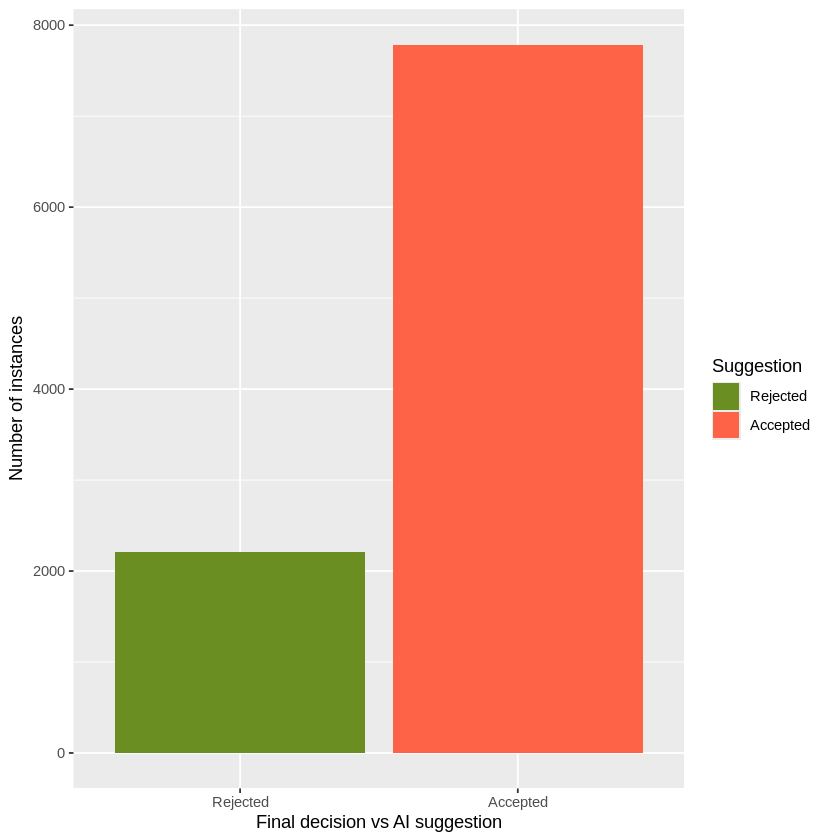

In [81]:

# agreement rate
g1 <- ggplot(or_sample, aes(agree)) + geom_bar(aes(fill=agree)) +
  labs(x="Final decision vs AI suggestion", y="Number of instances", fill="Suggestion") +
  scale_x_discrete(labels = c("TRUE" = "Accepted", "FALSE" = "Rejected"))+
  scale_fill_manual(values = c("TRUE" = "tomato1", "FALSE" = "olivedrab"), labels = c("TRUE"="Accepted", "FALSE"="Rejected"))
g1

Agreement is sometimes counted only on incorrect suggestions

$Agreement=p(F=A \mid A \ne ⊤)$

As the measure is a conditional probability, it is calculated on a reduced sample space of cases where the system is wrong. It is a number of cases where both incorrect suggestion and agreement occurs over all cases with incorrect suggestions:

$p(F=A \mid A \ne \top) = \frac{p(F=A \land A \ne \top)}{p(A \ne \top)}$

In [82]:
or_sample$incorrect = or_sample$prediction != or_sample$target
inc_agreement = sum(or_sample$agree==TRUE & or_sample$incorrect==TRUE) / sum(or_sample$incorrect==TRUE)
sprintf("Agreement level with incorrect suggestions: %.2f", inc_agreement)

[1] "Agreement level with incorrect suggestions: 0.31"

In [83]:
corr_agreement = sum(or_sample$agree==TRUE & or_sample$incorrect==FALSE) / sum(or_sample$incorrect==FALSE)
sprintf("Agreement level with correct suggestions: %.2f", corr_agreement)

[1] "Agreement level with correct suggestions: 0.93"

The number is quite large, however we may take in consideration the probability of intersection of two events:

$p(F=A \land A \ne \top) = p(F=A \mid A \ne \top ) \cdot p(A \ne \top)$

In [84]:
agreement_and_incorrect = inc_agreement * (sum(or_sample$incorrect==TRUE) / nrow(or_sample))
sprintf("Probability of suggestion being incorrect and accepted: %.2f", agreement_and_incorrect)

[1] "Probability of suggestion being incorrect and accepted: 0.07"

In [85]:
# In fact they are not independent
(sum(or_sample$agree==TRUE) / nrow(or_sample)) * (sum(or_sample$incorrect==TRUE) / nrow(or_sample))

[1] 0.1903143

In [86]:
or_sample$incorrect_labeled <- factor(or_sample$incorrect, levels=c(TRUE, FALSE), labels=c("Incorrect", "Correct"))

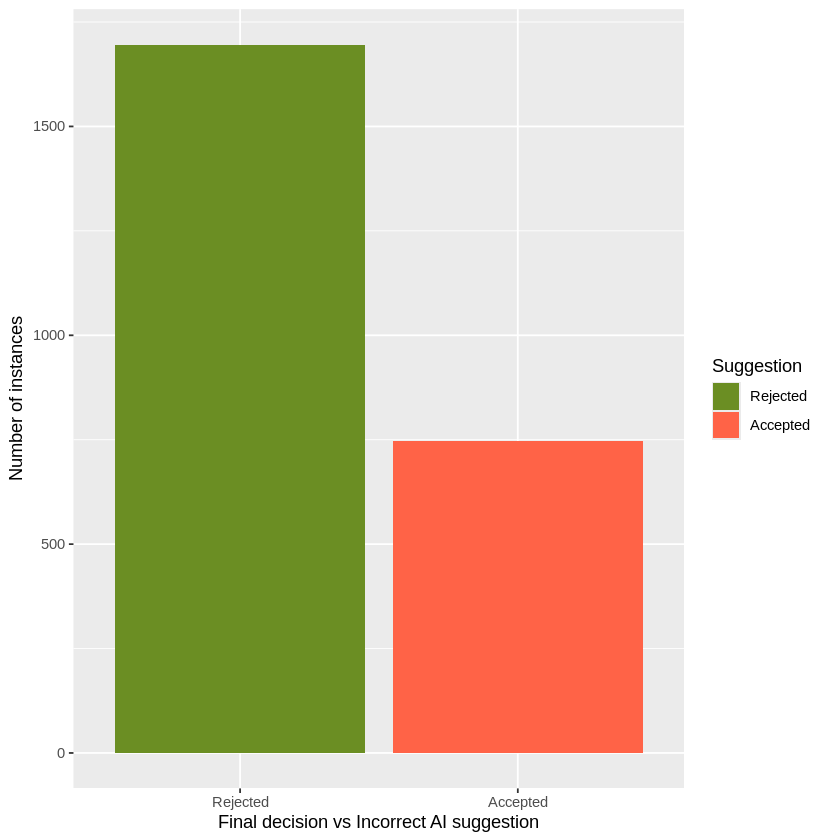

In [87]:
#agreement with incorrect suggestins
g2 <- ggplot(or_sample[or_sample$incorrect==TRUE, ], aes(agree)) + geom_bar(aes(fill=agree)) +
  labs(x="Final decision vs Incorrect AI suggestion", y="Number of instances", fill="Suggestion") +
  scale_x_discrete(labels = c("TRUE" = "Accepted", "FALSE" = "Rejected"))+
  scale_fill_manual(values = c("TRUE" = "tomato1", "FALSE" = "olivedrab"), labels = c("TRUE"="Accepted", "FALSE"="Rejected"))
g2

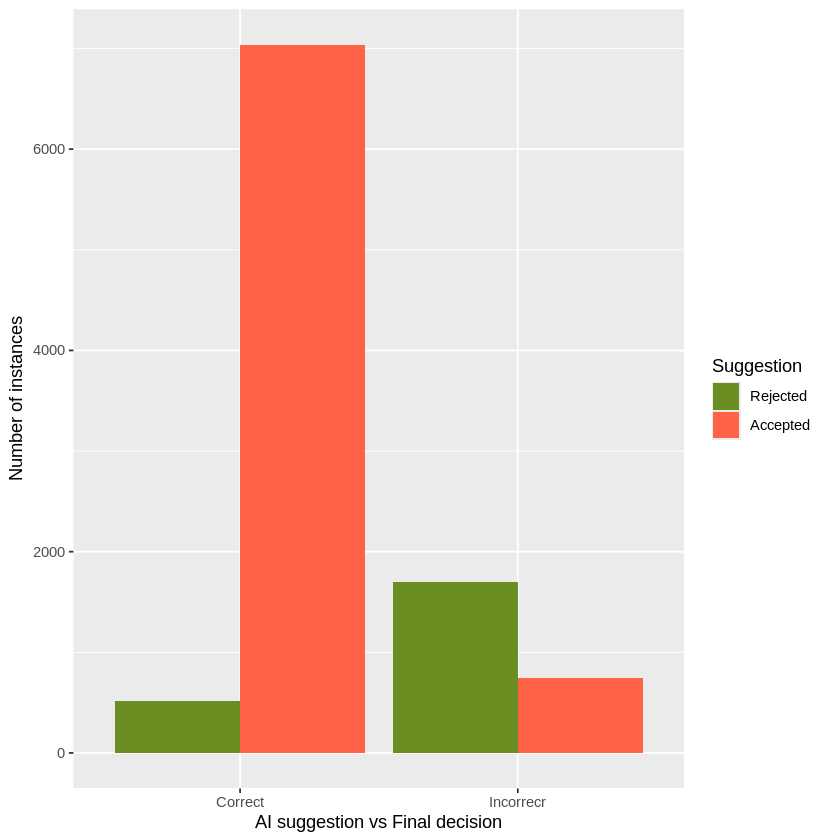

In [88]:
# side-by-side comparison
g2_1 <- ggplot(or_sample, aes(x=incorrect)) + geom_bar(aes(fill=agree), position = "dodge") +
  labs(x="AI suggestion vs Final decision", y="Number of instances", fill="Suggestion") +
  scale_x_discrete(labels = c("TRUE" = "Incorrecr", "FALSE" = "Correct"))+
  scale_fill_manual(values = c("TRUE" = "tomato1", "FALSE" = "olivedrab"), labels = c("TRUE"="Accepted", "FALSE"="Rejected"))
g2_1

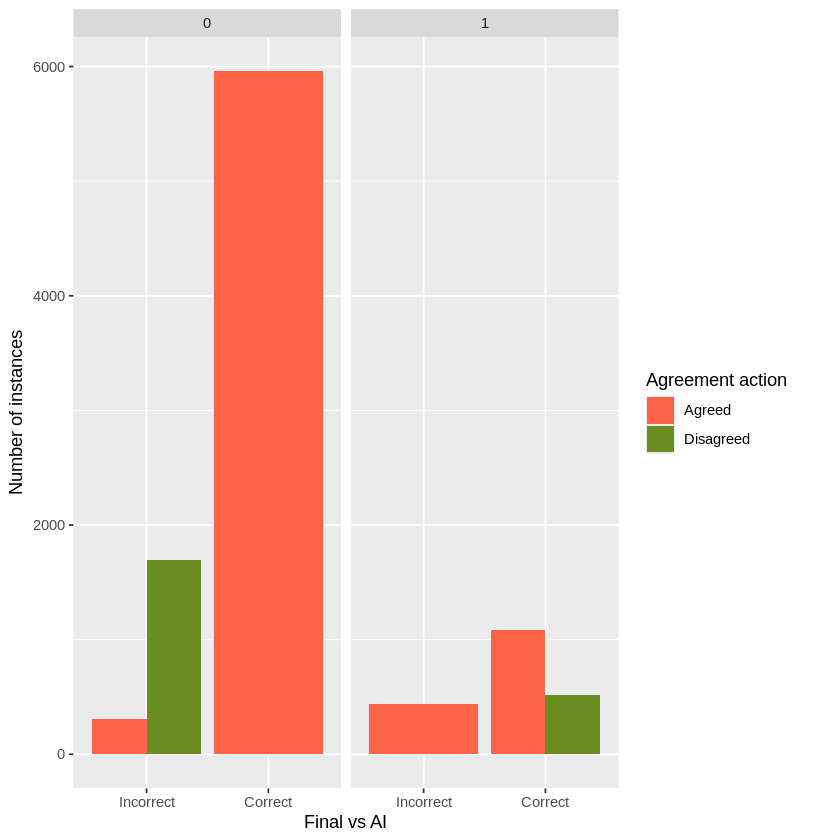

In [89]:
#side-by-side comparison for possible outcomes
g2_2 <- ggplot(or_sample, aes(x=incorrect_labeled, fill= agree_labeled)) + geom_bar(position="dodge") + facet_wrap(~target)+
  labs(x="Final vs AI", y="Number of instances", fill="Agreement action") +
  scale_fill_manual(values = c("Agreed" = "tomato1", "Disagreed" = "olivedrab"))
g2_2

In [90]:
# Probability of prediction being correct and accepted
corr_agreement * (sum(or_sample$incorrect==FALSE) / nrow(or_sample))

[1] 0.7039

### Distribution of agreement rates

In [91]:
agreement_l <- list()
for (t in 1: sample_size){
  ag = 0
  for (o in 1: task_size){
    if(final[[t]][o] == prediction[[t]][o]){ag = ag + 1}
  }
  ag = ag/task_size
  agreement_l[[t]] <- ag
}

In [92]:
length(agreement_l)

[1] 1000

In [93]:
observations <- data.frame(
  agreement = unlist(agreement_l)
)
head(observations)

,agreement
,<dbl>
1,0.9
2,1.0
3,1.0
4,0.8
5,0.4
6,0.9


In [94]:
summary(observations)

   agreement     
 Min.   :0.3000  
 1st Qu.:0.7000  
 Median :0.8000  
 Mean   :0.7787  
 3rd Qu.:0.9000  
 Max.   :1.0000  

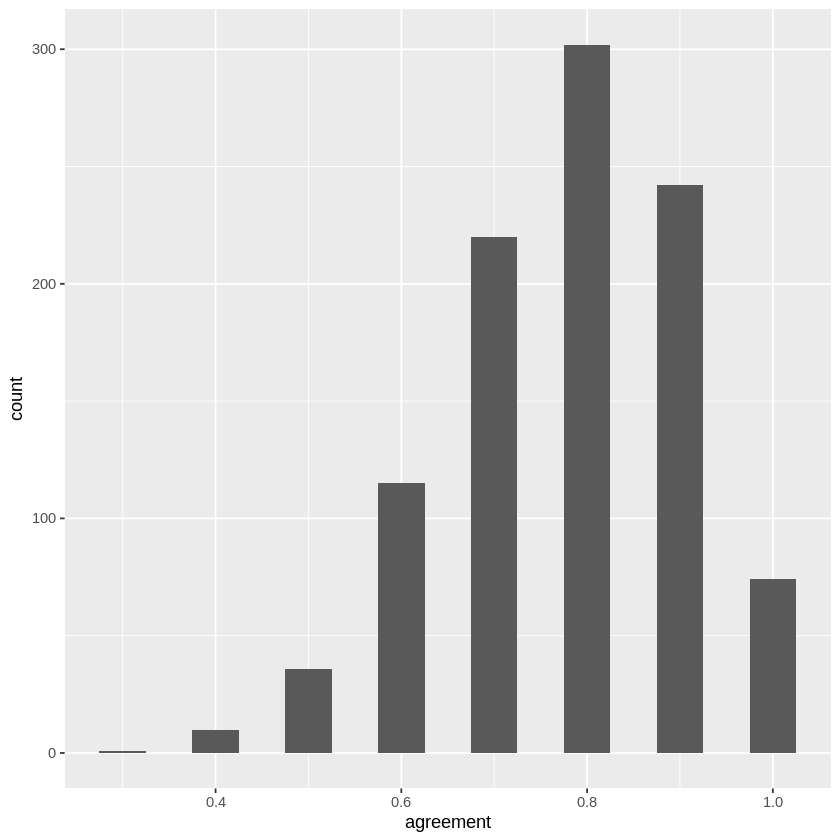

In [95]:
ggplot(observations, aes(x=agreement)) + geom_histogram(binwidth=0.05)

In [96]:
incagreement_l <- list()
for (t in 1: sample_size){
  agi = 0
  for (o in 1: task_size){
    if(final[[t]][o] == prediction[[t]][o] & prediction[[t]][o] != phenomenon[[t]][o]){agi = agi + 1}
  }
  agi = agi/task_size
  incagreement_l[[t]] <- agi
}

In [97]:
observations$incorrect_agreement = unlist(incagreement_l)

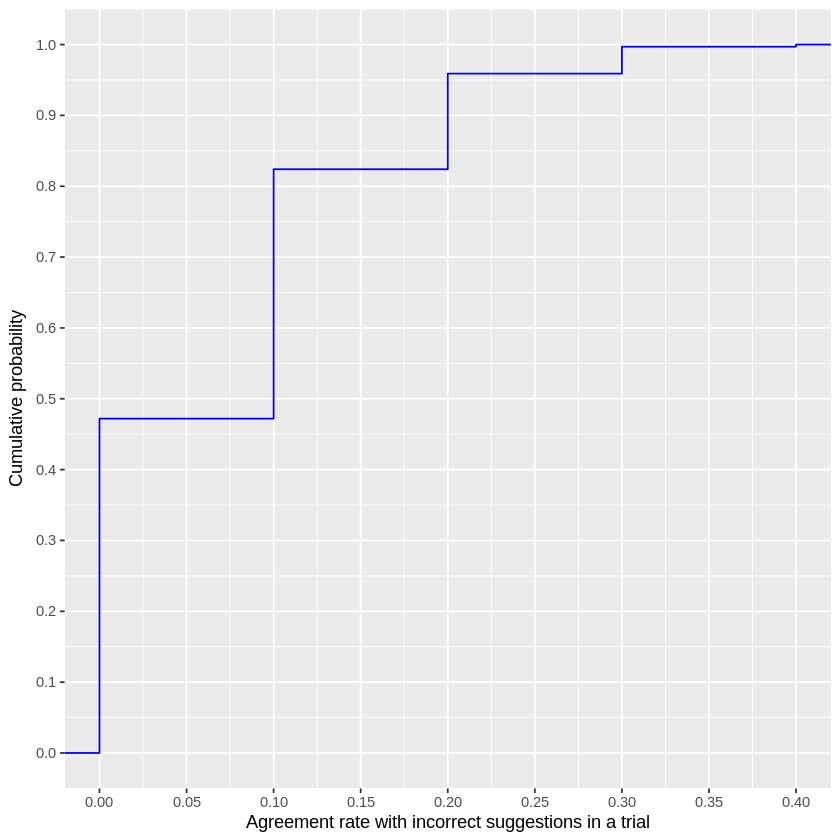

In [98]:
ggplot(observations, aes(x=incorrect_agreement)) + stat_ecdf(colour="blue") +
  labs(x="Agreement rate with incorrect suggestions in a trial", y="Cumulative probability")+ scale_x_continuous(n.breaks = 10) +
  scale_y_continuous(n.breaks = 10)

### Switch fraction

Switch fraction is defined as the number of decisions user switched to agree with the system over the total number of decisions where disagreement exists. We need to consider an additional variable: the initial decision.

 $p(F = A | H \ne A)$

In [99]:
or_sample$switch = or_sample$final == or_sample$prediction & or_sample$initial != or_sample$prediction

In [100]:
or_sample$disagreement = or_sample$initial != or_sample$prediction

In [101]:
switch_fraction = sum(or_sample$switch) / sum(or_sample$initial != or_sample$prediction)
sprintf("Switch fraction: %.2f", switch_fraction)

[1] "Switch fraction: 0.34"

Although there are no such cases in our dataset, it is possible that user change their mind even in the case of a confirming suggestion, the effect known is the dilution of the evidence effect.

In [102]:
or_sample$switch_labeled <- factor(or_sample$switch, levels=c(TRUE, FALSE), labels=c("Switched", "Remained"))

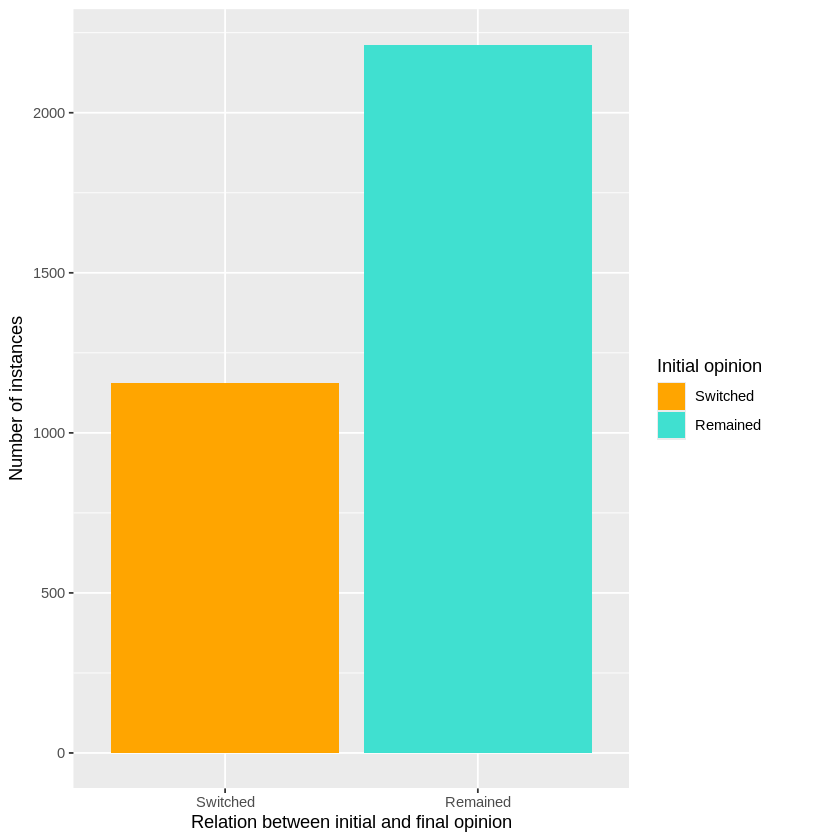

In [103]:
# switch fraction
g3 <- ggplot(or_sample[or_sample$initial != or_sample$prediction,], aes(x=reorder(switch_labeled, switch_labeled, function(x)+length(x)))) + geom_bar(aes(fill=switch_labeled)) +
  labs(x="Relation between initial and final opinion", y="Number of instances", fill="Initial opinion") +
  scale_fill_manual(values = c("Remained" = "turquoise", "Switched" = "orange"))
g3

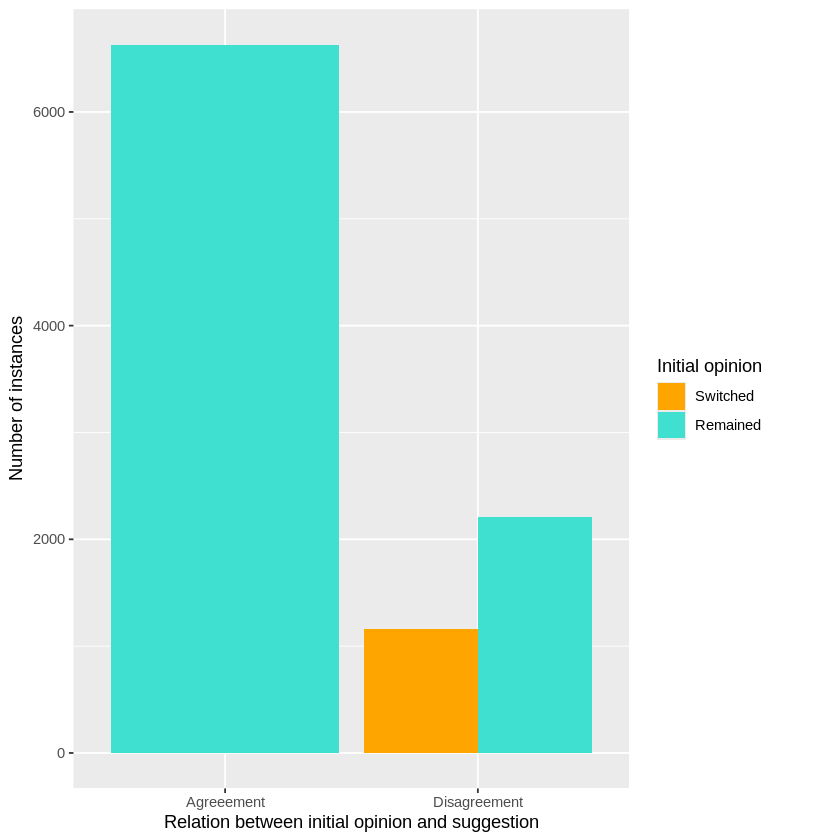

In [104]:
# side-by-side comparison with initial agreement
g4 <- ggplot(or_sample, aes(x=disagreement, fill= switch_labeled)) + geom_bar(position="dodge") +
  labs(x="Relation between initial opinion and suggestion", y="Number of instances", fill="Initial opinion") +
  scale_x_discrete(labels = c(
    "TRUE" = "Disagreement",
    "FALSE" = "Agreeement"))+
    scale_fill_manual(values = c("Remained" = "turquoise", "Switched" = "orange"))

g4

Also switch fraction may be calculated on incorrect suggestions

In [105]:
switch_fraction_incorrect = sum(or_sample$final == or_sample$prediction & or_sample$initial != or_sample$prediction & or_sample$prediction != or_sample$target) / sum(or_sample$initial != or_sample$prediction & or_sample$prediction != or_sample$target)
sprintf("Switch fraction on incorrect predictions: %.2f", switch_fraction_incorrect)

[1] "Switch fraction on incorrect predictions: 0.14"

In [106]:
switch_fraction_correct = sum(or_sample$final == or_sample$prediction & or_sample$initial != or_sample$prediction & or_sample$prediction == or_sample$target) / sum(or_sample$initial != or_sample$prediction & or_sample$prediction == or_sample$target)
sprintf("Switch fraction on correct predictions: %.2f", switch_fraction_correct)

[1] "Switch fraction on correct predictions: 0.63"

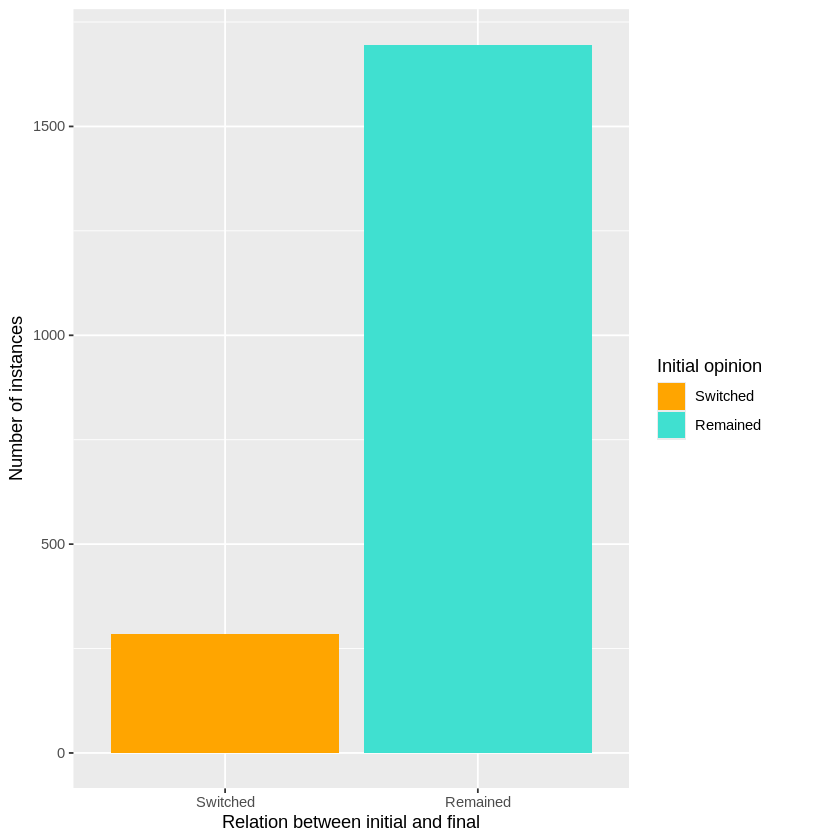

In [107]:
#switch to incorrect
g5 <- ggplot(or_sample[or_sample$initial != or_sample$prediction & or_sample$incorrect==TRUE, ], aes(switch_labeled)) + geom_bar(aes(fill=switch_labeled)) +
  labs(x="Relation between initial and final", y="Number of instances", fill="Initial opinion") +
  scale_fill_manual(values = c("Remained" = "turquoise", "Switched" = "orange"))
g5

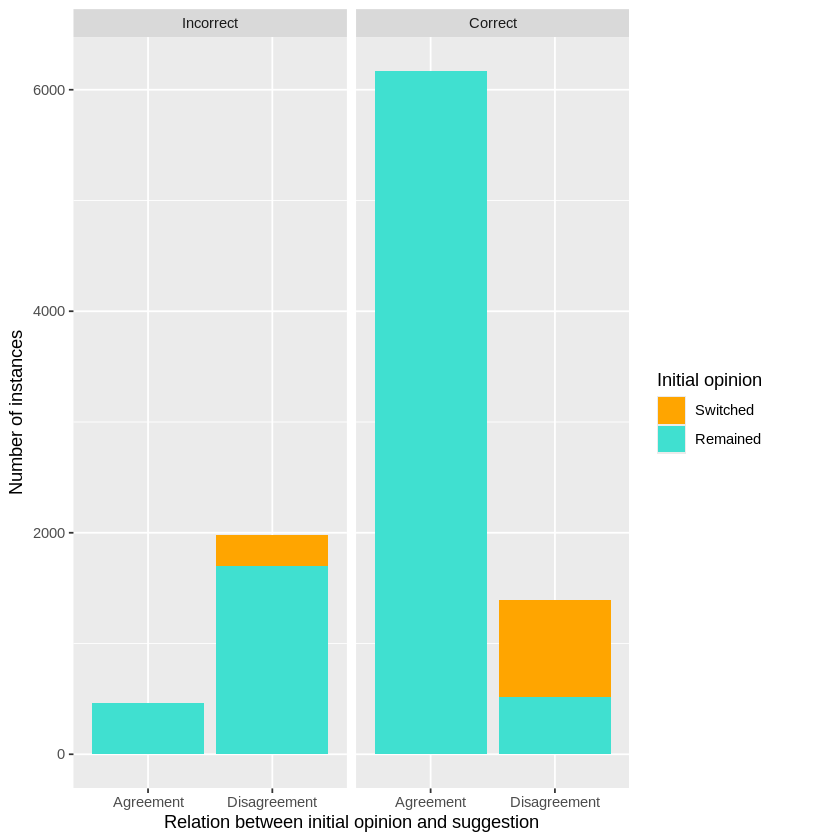

In [108]:
g6 <- ggplot(or_sample, aes(x=disagreement, fill=switch_labeled)) + geom_bar() + facet_wrap(~incorrect_labeled) +
  scale_x_discrete(labels = c("TRUE" = "Disagreement", "FALSE"="Agreement")) +
  scale_fill_manual(values = c("Remained" = "turquoise", "Switched" = "orange")) +
  labs(x="Relation between initial opinion and suggestion", y="Number of instances", fill = "Initial opinion")
g6

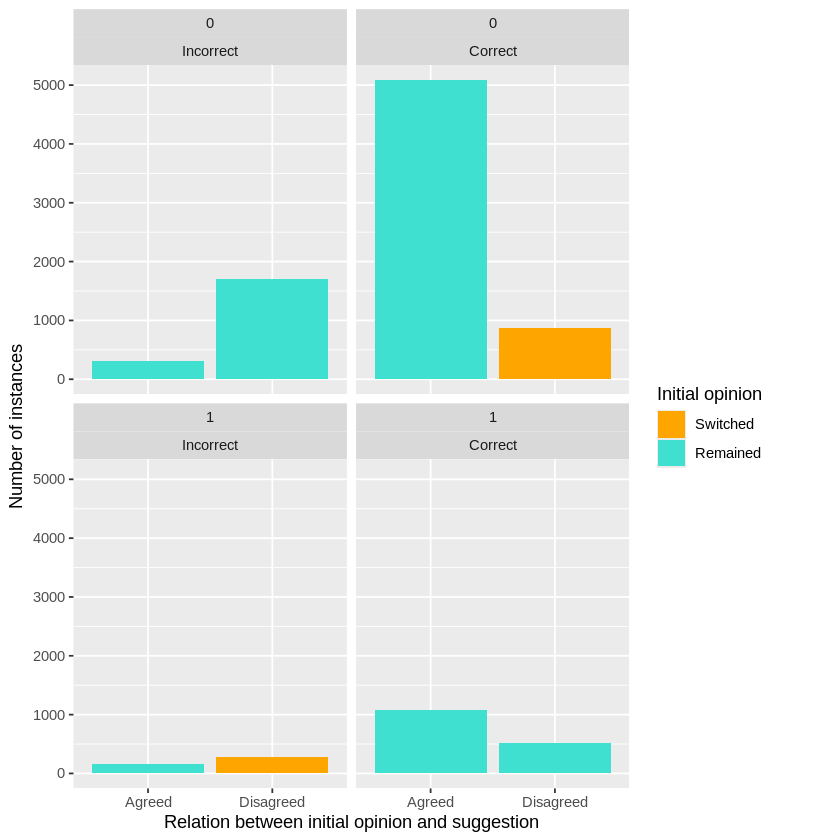

In [109]:
g7 <- ggplot(or_sample, aes(x=disagreement, fill=switch_labeled)) + geom_bar() + facet_wrap(target~incorrect_labeled) +
  scale_x_discrete(labels = c("TRUE" = "Disagreed", "FALSE"="Agreed")) +
  scale_fill_manual(values = c("Remained" = "turquoise", "Switched" = "orange")) +
  labs(x="Relation between initial opinion and suggestion", y="Number of instances", fill = "Initial opinion")
g7

### Appropriate reliance

RAIR - relative AI reliance is the ration between $CAIR$ "which describes the case when the human is initially incorrect, receives correct advice, and relies on that advice". Instance-CAIR is equal to 1 when "the original human decision was wrong, the AI recommendation was correct and the human decision after receiving the AI recommendation is correct, and 0 otherwise". Instance CA is "one if the original human decision was wrong and the AI advice was correct"

$CAIR( H \ne \top \land H \ne A \land A = \top \land F = A) = 1$

 or, given that for binary decision the third element is redundant:

$CAIR(H \ne \top \land H \ne A \land F = A) = 1$, 0 otherwise

It is not defined on cases where $F=H=A$ and $H=A\land F \ne A(F \ne H)$


$CA(H \ne A \land H \ne T) = 1$, 0 otherwise

Therfore, RAIR is the switch fraction to correct prediction

In [110]:
cair = sum(or_sample$final == or_sample$prediction & or_sample$initial != or_sample$prediction & or_sample$prediction == or_sample$target)
ca = sum(or_sample$initial != or_sample$prediction & or_sample$prediction == or_sample$target)
rair = cair / ca
sprintf("CAIR: %.2f", cair)
sprintf("CA: %.2f", ca)
sprintf("Relative AI reliance RAIR: %.2f", rair)

[1] "CAIR: 872.00"

[1] "CA: 1389.00"

[1] "Relative AI reliance RAIR: 0.63"

In [111]:
cair1 = sum(or_sample$final == or_sample$prediction & or_sample$initial != or_sample$prediction & or_sample$prediction == or_sample$target & or_sample$target == 1)
ca1 = sum(or_sample$initial != or_sample$prediction & or_sample$prediction == or_sample$target & or_sample$target == 1)
rair1 = cair1 / ca1
sprintf("CAIR: %.2f", cair1)
sprintf("CA: %.2f", ca1)
sprintf("Relative AI reliance RAIR on case 1: %.2f", rair1)

[1] "CAIR: 0.00"

[1] "CA: 517.00"

[1] "Relative AI reliance RAIR on case 1: 0.00"

In [112]:
cair0 = sum(or_sample$final == or_sample$prediction & or_sample$initial != or_sample$prediction & or_sample$prediction == or_sample$target & or_sample$target == 0)
ca0 = sum(or_sample$initial != or_sample$prediction & or_sample$prediction == or_sample$target & or_sample$target == 0)
rair0 = cair0 / ca0
sprintf("CAIR: %.2f", cair0)
sprintf("CA: %.2f", ca0)
sprintf("Relative AI reliance RAIR on case 0: %.2f", rair0)

[1] "CAIR: 872.00"

[1] "CA: 872.00"

[1] "Relative AI reliance RAIR on case 0: 1.00"

RSR - relative self reliance is the ration between $CSR$ "which describes the case when the human is initially correct, receives incorrect advice, and relies on herself". Instance-CSR is equal to 1 when "the initial human decision was correct, the AI advice was incorrect and the human decision after receiving AI advice is correct (and 0 otherwise?). Instance IA is "one if initial human decision  was correct and the AI advice was incorrect"

$CSR( H = T \land H \ne AI \land AI \ne T \land F = H) = 1$

 or, given that for binary decision the third element is redundant:

$CSR(H = T \land H \ne AI \land F = H) = 1$, 0 otherwise

(?) It is not defined on cases where $F=H=AI$ and $H=AI \land F \ne AI (F \ne H)$


$IA(H \ne AI \land H = T) = 1$, 0 otherwise

CSR therefore is the "remain" fraction for correct opinion

In [113]:
csr = sum(or_sample$final == or_sample$initial & or_sample$initial != or_sample$prediction & or_sample$initial == or_sample$target)
ia = sum(or_sample$initial != or_sample$prediction & or_sample$initial == or_sample$target)
rsr = csr / ia
sprintf("Correct self-reliance (CSR): %.2f", csr)
sprintf("Incorrect AI (IA): %.2f", ia)
sprintf("Relative self reliance: %.2f", rsr)

[1] "Correct self-reliance (CSR): 1696.00"

[1] "Incorrect AI (IA): 1980.00"

[1] "Relative self reliance: 0.86"

In [114]:
sprintf("Appropriate reliance tuple: (%.2f, %.2f)", rair, rsr)

[1] "Appropriate reliance tuple: (0.63, 0.86)"

In [115]:
before_accuracy = sum(or_sample$initial== or_sample$target) / nrow(or_sample)
ai_accuracy = sum(or_sample$prediction== or_sample$target) /nrow(or_sample)
after_accuracy = sum(or_sample$final == or_sample$target) / nrow(or_sample)

sprintf("Human accuracy: %.2f", before_accuracy)
sprintf("AI accuracy: %.2f", ai_accuracy)
sprintf("After accuracy: %.2f", after_accuracy)
cat("\n")

if(after_accuracy > max(before_accuracy, ai_accuracy)){appropriate_reliance2 = 1}else{appropriate_reliance2 = 0}

sprintf("Appropriate reliance 2: %d", appropriate_reliance2)

[1] "Human accuracy: 0.81"

[1] "AI accuracy: 0.76"

[1] "After accuracy: 0.87"

[1] "Appropriate reliance 2: 1"

In [116]:
sprintf("Relative AI reliance or switch to correct suggestion: %.2f", rair)

n1 = sum(or_sample$final == or_sample$initial & or_sample$initial != or_sample$prediction & or_sample$prediction == or_sample$target)
d1 = sum(or_sample$initial != or_sample$prediction & or_sample$prediction == or_sample$target)
m1 = n1 / d1

sprintf("Resistence to correct suggestion: %.2f", m1)

[1] "Relative AI reliance or switch to correct suggestion: 0.63"

[1] "Resistence to correct suggestion: 0.37"

In [117]:

sprintf("Relative self reliance or resistence to incorrect suggestion: %.2f", rsr)
sprintf("Change from correct opinion or switch fraction to incorrect: %.2f", switch_fraction_incorrect)

[1] "Relative self reliance or resistence to incorrect suggestion: 0.86"

[1] "Change from correct opinion or switch fraction to incorrect: 0.14"

## Evaluating a measure similar to Bayes factor for human intervention

In [118]:
# correct final decision when prediction are actually correct (or relative AI reliance)
sens = sum(or_sample$final == or_sample$prediction & or_sample$initial != or_sample$prediction & or_sample$prediction == or_sample$target) /
  sum(or_sample$initial != or_sample$prediction & or_sample$prediction == or_sample$target)
  sens

[1] 0.6277898

In [119]:
# correct final decision when prediction are incorrect
spec = sum(or_sample$final == or_sample$initial & or_sample$initial != or_sample$prediction & or_sample$prediction != or_sample$target) /
  sum(or_sample$initial != or_sample$prediction & or_sample$prediction != or_sample$target)
  spec

[1] 0.8565657

In [120]:
#positive likelihood ratio
LRpos = sens/(1-spec)
LRpos

[1] 4.376844

In [121]:
#prior odds
preodds = (sum(or_sample$prediction == or_sample$target)/nrow(or_sample)) / (sum(or_sample$prediction != or_sample$target)/nrow(or_sample))
preodds

[1] 3.091653

In [122]:
# posterior odds
postodds = preodds * LRpos
postodds

[1] 13.53168

In [123]:
# ratio
postodds / (1+postodds)

[1] 0.9311848

## Visualising joint decision-making

In [124]:
htpr = sum(or_sample$initial == or_sample$target & or_sample$target == 1) / sum(or_sample$target == 1)
htnr = sum(or_sample$initial == or_sample$target & or_sample$target == 0) / sum(or_sample$target == 0)
aitpr = sum(or_sample$prediction == or_sample$target & or_sample$target == 1) / sum(or_sample$target == 1)
aitnr = sum(or_sample$prediction == or_sample$target & or_sample$target == 0) / sum(or_sample$target == 0)
jtpr = sum(or_sample$final == or_sample$target & or_sample$target == 1) / sum(or_sample$target == 1)
jtnr = sum(or_sample$final == or_sample$target & or_sample$target == 0) / sum(or_sample$target == 0)
cat("Human TPR: ", htpr, "\n")
cat("Human TNR: ", htnr, "\n")
cat("AI TPR: ", aitpr, "\n")
cat("AI TNR: ", aitnr, "\n")
cat("Joint TPR: ", jtpr, "\n")
cat("Joint TNR: ", jtnr, "\n")

Human TPR:  0.6705998 
Human TNR:  0.8514938 
AI TPR:  0.7851524 
AI TNR:  0.7480542 
Joint TPR:  0.5309735 
Joint TNR:  0.9609591 


In [125]:
summary_df <- data.frame (
  Type = c("Human", "Human", "AI", "AI", "Joint", "Joint"),
  Case = c("Present", "Absent","Present", "Absent","Present", "Absent"),
  Accuracy = c(htpr, htnr, aitpr, aitnr, jtpr, jtnr)
)

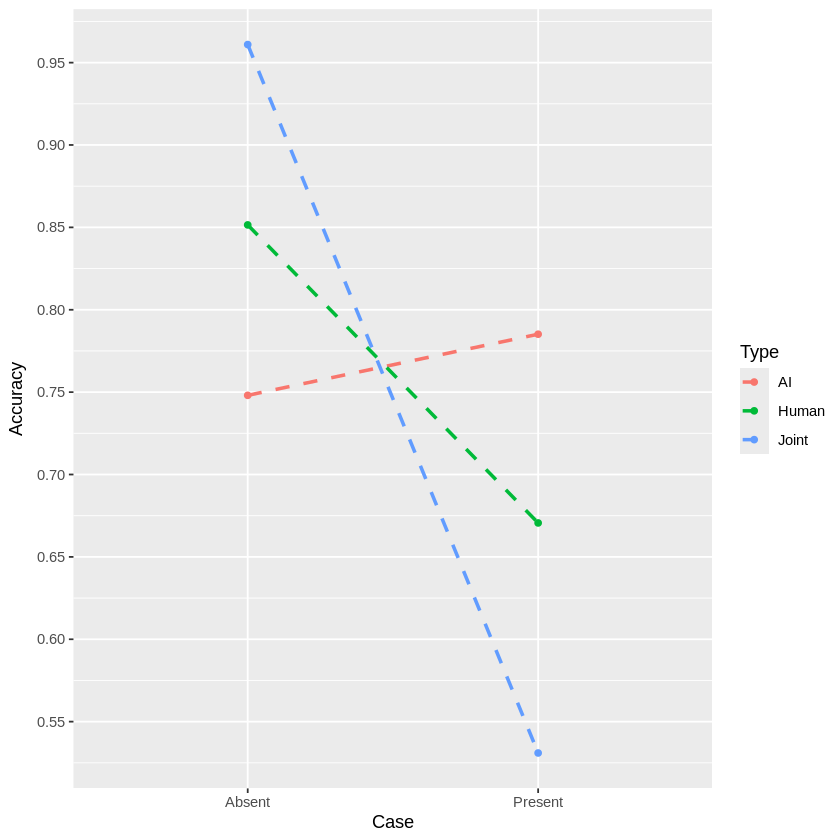

In [126]:
ggplot(summary_df, aes(x=Case, y=Accuracy, color=Type, group=Type)) + geom_point() + geom_line(linetype = "dashed", linewidth = 1) + scale_y_continuous(n.breaks = 10)